Introduction

**Project Title: Sentiment Analysis of Customer Reviews using LSTM Models**

Objective:

The goal of this project is to perform sentiment analysis on customer reviews from the Amazon Food Reviews dataset. Sentiment analysis is a natural language processing (NLP) task that involves determining the emotional tone or opinion expressed in a piece of text. In this project, we will classify customer reviews into three sentiment categories:

Positive (4-5 stars)

Neutral (3 stars)

Negative (1-2 stars)

We will use Long Short-Term Memory (LSTM) models, a type of recurrent neural network (RNN), to capture the sequential nature of text data and predict sentiment labels.

**Dataset**

The dataset used in this project is the Amazon Fine Food Reviews dataset, which contains:

Review Text: The textual content of the review.

Score: A rating between 1 and 5, indicating the customer's satisfaction level.

The dataset is preprocessed to clean the text, map scores to sentiment labels, and split into training, validation, and test sets.

Steps Involved:
Data Preprocessing:

Clean the text (remove special characters, convert to lowercase, etc.).

Map review scores to sentiment labels (Positive, Neutral, Negative).

Split the dataset into training, validation, and test sets.

Word Embedding:

Tokenize the text and convert it into sequences of integers.

Pad sequences to ensure uniform input size for the model.

Model Development:

Build an LSTM-based deep learning model using Keras.

Use an embedding layer to convert words into dense vectors.

Training and Validation:

Train the model on the training dataset.

Validate the model using the validation set to monitor performance.

Evaluation:

Evaluate the model on the test set using metrics like accuracy, precision, recall, and F1-score.

Optimization:

Fine-tune hyperparameters (e.g., LSTM units, embedding dimensions, dropout rates) to improve performance.

Deployment :

Save the trained model and deploy it as an API using frameworks like Flask or FastAPI.

Tools and Libraries:
Python: Primary programming language.

Pandas: For data manipulation and analysis.

NumPy: For numerical computations.

TensorFlow/Keras: For building and training the LSTM model.

Scikit-learn: For data splitting and evaluation metrics.

Matplotlib/Seaborn: For data visualization.

Expected Outcome:
By the end of this project, we aim to build a robust sentiment analysis model that can accurately classify customer reviews into positive, neutral, and negative categories. This model can be used by businesses to gain insights into customer feedback and improve their products or services.

Step 1: Load the Dataset

The Amazon Food Reviews dataset typically contains columns like:

Review Text: The text of the review.

Score: A rating between 1 and 5 (1-2 = Negative, 3 = Neutral, 4-5 = Positive).

You can load the dataset using pandas:

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Reviews.csv')
print(df.head())

   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                                               Text  
0  Good Quality Dog Food  I have bought several of the Vitality canned d...  
1 

Step 2: Data Preprocessing

2.1. Clean the Text
Clean the review text by removing unnecessary characters, converting to lowercase, etc

In [3]:
import re

def clean_text(text):
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    return text

df['Cleaned_Review'] = df['Text'].apply(clean_text)

**Class Distribution**

Visualize the distribution of sentiment labels (Positive, Neutral, Negative) in your dataset.

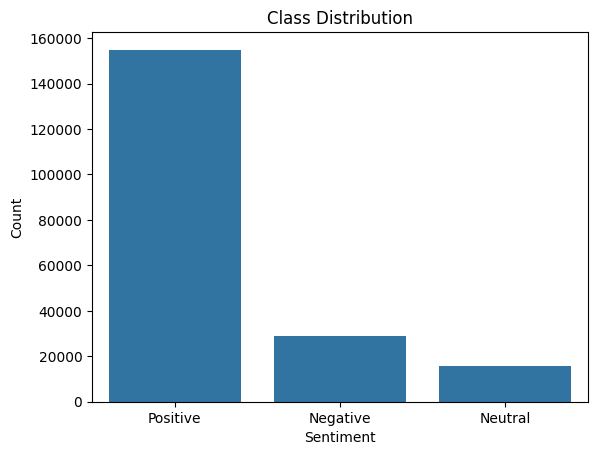

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot class distribution
sns.countplot(x=df['Sentiment'])
plt.title('Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

**Word Cloud**

Create a word cloud to visualize the most frequent words in the reviews.

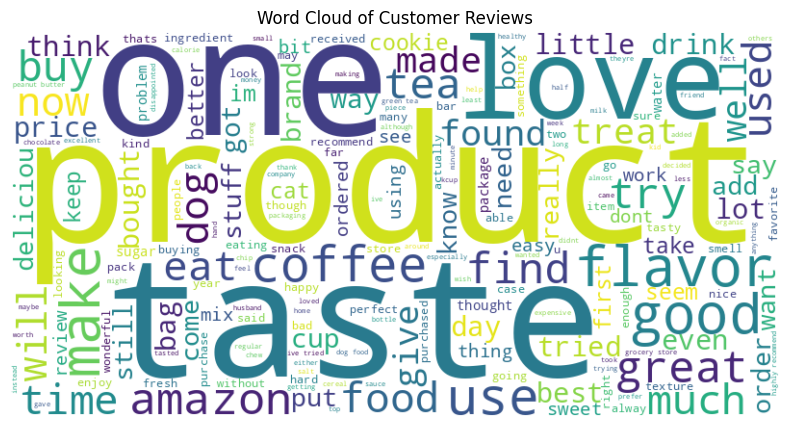

In [14]:
from wordcloud import WordCloud

# Combine all reviews into a single string
all_reviews = ' '.join(df['Cleaned_Review'])

# Generate a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_reviews)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Customer Reviews')
plt.show()

2.2. Map Scores to Sentiment Labels

Convert the Score column into sentiment labels (Positive, Neutral, Negative).

In [4]:
def map_sentiment(score):
    if score <= 2:
        return 'Negative'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['Sentiment'] = df['Score'].apply(map_sentiment)

2.3. Encode Sentiment Labels

Convert sentiment labels into numerical values.

In [5]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['Sentiment_Encoded'] = label_encoder.fit_transform(df['Sentiment'])

2.4. Split the Dataset

Split the dataset into training, validation, and test sets.

In [6]:
from sklearn.model_selection import train_test_split

X = df['Cleaned_Review']
y = df['Sentiment_Encoded']

# Split into training (70%), validation (15%), and test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

**Step 3: Word Embedding**

3.1. Tokenization
Tokenize the text and convert it into sequences of integers.

In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenize the text
tokenizer = Tokenizer(num_words=10000)  # Adjust vocab size as needed
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences to ensure uniform length
max_length = 100  # Adjust based on your dataset
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_length, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post')

**Step 4: Model Development**

Build an LSTM model using Keras.

In [11]:
import numpy as np

# Build the model by passing a sample input
sample_input = np.zeros((1, max_length))  # Sample input with shape (batch_size, max_length)
model(sample_input)

# Print model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (1, 100, 128)               │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (1, 128)                    │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (1, 128)                    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (1, 64)                     │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (1, 3)                      │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,420,035 (5.42 MB)

 Trainable params: 1,420,035 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

**Step 5: Training and Validation**

Train the model and validate it.

In [15]:
history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,  # Adjust as needed
    batch_size=64
)

Epoch 1/10
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 628s 286ms/step - accuracy: 0.7762 - loss: 0.6672 - val_accuracy: 0.8439 - val_loss: 0.4336
Epoch 2/10
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 664s 305ms/step - accuracy: 0.8552 - loss: 0.3976 - val_accuracy: 0.8659 - val_loss: 0.3639
Epoch 3/10
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 768s 352ms/step - accuracy: 0.8796 - loss: 0.3185 - val_accuracy: 0.8723 - val_loss: 0.3402
Epoch 4/10
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 660s 287ms/step - accuracy: 0.9011 - loss: 0.2666 - val_accuracy: 0.8780 - val_loss: 0.3306
Epoch 5/10
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 619s 284ms/step - accuracy: 0.9212 - loss: 0.2184 - val_accuracy: 0.8816 - val_loss: 0.3469
Epoch 6/10
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 623s 285ms/step - accuracy: 0.9343 - loss: 0.1848 - val_accuracy: 0.8825 - val_loss: 0.3756
Epoch 7/10
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 617s 283ms/step - accuracy: 0.9478 - loss: 0.1532 - val_accuracy: 0.8842 - val_loss: 0.3808
Epoch 8/10
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 624s 284ms/step - ac

**Loss and Accuracy Curves**

Plot the training and validation loss/accuracy to monitor the model's performance during training.

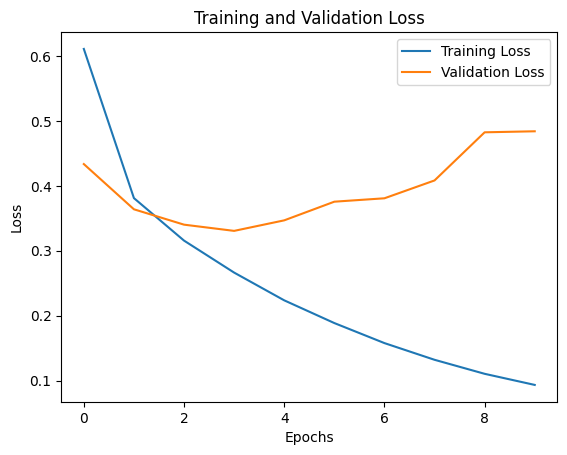

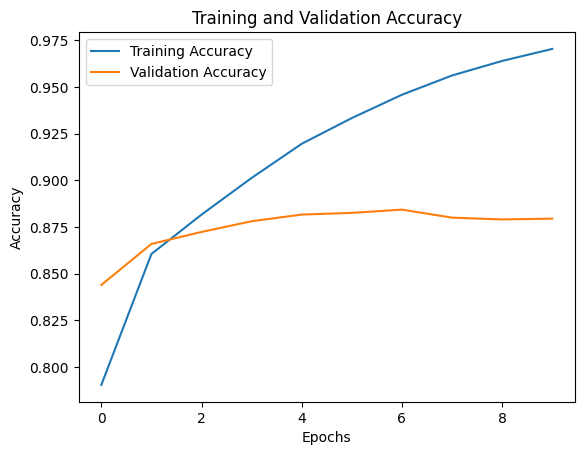

In [16]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**Embedding Visualization**

If you're curious about the word embeddings learned by the model, you can visualize them using t-SNE or PCA.

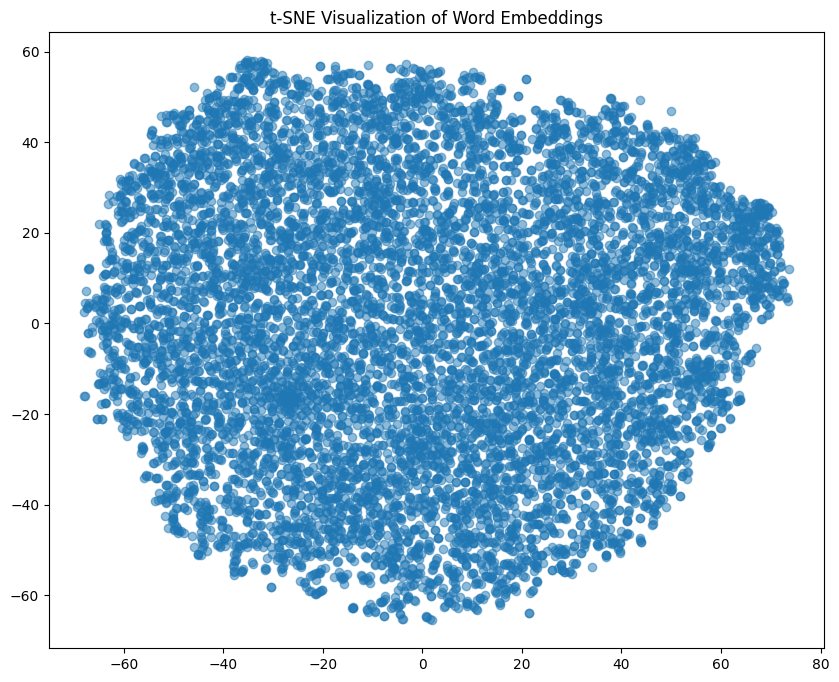

In [17]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Get the embedding layer weights
embedding_weights = model.layers[0].get_weights()[0]

# Reduce dimensionality using t-SNE
tsne = TSNE(n_components=2, random_state=42)
embedding_tsne = tsne.fit_transform(embedding_weights)

# Plot the embeddings
plt.figure(figsize=(10, 8))
plt.scatter(embedding_tsne[:, 0], embedding_tsne[:, 1], alpha=0.5)
plt.title('t-SNE Visualization of Word Embeddings')
plt.show()

**Step 6: Evaluation**

Evaluate the model on the test set

In [18]:
loss, accuracy = model.evaluate(X_test_pad, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

934/934 ━━━━━━━━━━━━━━━━━━━━ 62s 66ms/step - accuracy: 0.8785 - loss: 0.4889
Test Accuracy: 0.8770


**Confusion Matrix**

Visualize the confusion matrix to see how well the model is performing on the test set.

934/934 ━━━━━━━━━━━━━━━━━━━━ 61s 65ms/step


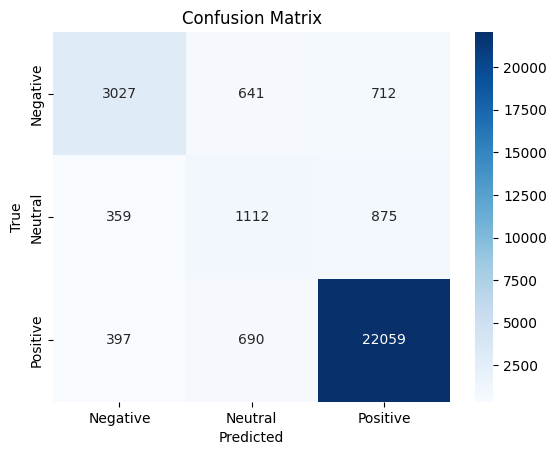

In [19]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Get predictions
y_pred = model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Step 7: Optimization

Experiment with hyperparameters (e.g., LSTM units, embedding dimensions, dropout rates).

Use techniques like Bidirectional LSTM or GRU for better performance.

Perform grid search or random search for hyperparameter tuning.

Grid Search for Hyperparameter Tuning

Use GridSearchCV or RandomizedSearchCV from scikit-learn to automate hyperparameter tuning. However, since Keras models are not directly compatible with scikit-learn, you can use KerasClassifier or KerasRegressor wrappers.

 Regularization Techniques

Regularization helps prevent overfitting. You can use:

Dropout: Randomly drop units during training.

L2 Regularization: Add a penalty to the loss function for large weights.

In [21]:
from tensorflow.keras.regularizers import l2

model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length))
model.add(LSTM(units=128, return_sequences=False, kernel_regularizer=l2(0.01)))
model.add(Dropout(0.5))
model.add(Dense(units=64, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dense(units=3, activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Advanced Architectures

Experiment with more advanced architectures to improve performance:

Bidirectional LSTM: Processes the input sequence in both forward and backward directions.

GRU (Gated Recurrent Unit): A simpler alternative to LSTM with fewer parameters.

In [22]:
from tensorflow.keras.layers import Bidirectional

model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length))
model.add(Bidirectional(LSTM(units=128, return_sequences=False)))
model.add(Dropout(0.5))
model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=3, activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

Early Stopping

Early stopping prevents overfitting by stopping training when the validation loss stops improving.

Learning Rate Scheduling

Adjust the learning rate during training to improve convergence.

Evaluate the Optimized Model

After optimization, evaluate the model on the test set to check its performance.

In [25]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test_pad, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

934/934 ━━━━━━━━━━━━━━━━━━━━ 156s 167ms/step - accuracy: 0.7721 - loss: 0.6336
Test Accuracy: 0.7750


step 8: Deployment

Save the trained model and deploy it using a framework like Flask or FastAPI

In [27]:
model.save('my_model.keras')